In [1]:
import json
import csv
import os
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupShuffleSplit

In [2]:
def reformat(in_path, out_path):
    # shutil.unpack_archive(zip_path, extract_to)

    DATASET_ROOT = Path(in_path)

    OUTPUT_DIR = Path(out_path)

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    IMAGES_DIR = OUTPUT_DIR / "images"

    csv_path = OUTPUT_DIR / "labels.csv"

    with open(csv_path, "w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)

        writer.writerow([
            "image_name",
            "x",
            "y",
            "subject_ID"
        ])

        total_images = 0
        total_subjects = 0

        # ======================================================
        # Alle Subjekte durchlaufen
        # ======================================================

        for outer_subject_dir in sorted(DATASET_ROOT.iterdir()):

            if not outer_subject_dir.is_dir():
                continue

            subject_id = outer_subject_dir.name

            inner_subject_dir = (
                outer_subject_dir / subject_id
            )

            if not inner_subject_dir.exists():
                continue

            # ==================================================
            # Dateien laden
            # ==================================================

            frames_file = (
                inner_subject_dir / "frames.json"
            )

            dotinfo_file = (
                inner_subject_dir / "dotInfo.json"
            )

            frames_folder = (
                inner_subject_dir / "frames"
            )

            # --------------------------------------------------
            if not frames_file.exists():
                print(f"Skipping {subject_id}: frames.json missing")
                # skipped_subjects += 1
                continue

            if not dotinfo_file.exists():
                print(f"Skipping {subject_id}: dotInfo.json missing")
                # skipped_subjects += 1
                continue

            if not frames_folder.exists():
                print(f"Skipping {subject_id}: frames folder missing")
                # skipped_subjects += 1
                continue

            # --------------------------------------------------

            try:
                with open(frames_file, "r", encoding="utf-8") as f:
                    frame_names = json.load(f)

                with open(dotinfo_file, "r", encoding="utf-8") as f:
                    dot_info = json.load(f)


            except Exception as e:
                print(f"Skipping {subject_id}: JSON read error --> {e}")

            try:
                x_values = dot_info["XPts"]
                y_values = dot_info["YPts"]

            except KeyError as e:
                print(f"Skipping {subject_id}: missing key --> {e}")

            if len(frame_names) != len(x_values):
                print(
                    f"ERROR in {subject_id}: "
                    f"{len(frame_names)} frames but "
                    f"{len(x_values)} labels"
                )
                continue

            total_subjects += 1

            # ==================================================
            # Alle Frames bearbeiten
            # ==================================================

            for idx in range(len(frame_names)):

                original_image_name = frame_names[idx]

                x = x_values[idx]
                y = y_values[idx]

                source_image = (
                    frames_folder /
                    original_image_name
                )

                if not source_image.exists():
                    print(
                        f"Missing image: {source_image}"
                    )
                    continue

                writer.writerow([
                    source_image,
                    x,
                    y,
                    subject_id
                ])

                total_images += 1

    print()
    print("=" * 50)
    print("DONE")
    print("=" * 50)
    print(f"Subjects processed\t: {total_subjects}")
    print(f"Images processed\t: {total_images}")
    print(f"CSV saved to\t\t: {csv_path}")

In [25]:
# 3: Normalization:

def normalize(in_path, out_path):

    DATASET_ROOT = Path(in_path)

    OUTPUT_DIR = Path(out_path)

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    IMAGES_DIR = OUTPUT_DIR / "images"

    csv_path = OUTPUT_DIR / "norm_labels.csv"

    with open(csv_path, "w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)

        writer.writerow([
            "image_name",
            "x_norm",
            "y_norm",
            "subject_ID",
            "screen_w",
            "screen_h"
        ])

        total_images = 0
        total_subjects = 0

        # ======================================================
        # Alle Subjekte durchlaufen
        # ======================================================

        for outer_subject_dir in sorted(DATASET_ROOT.iterdir()):

            if not outer_subject_dir.is_dir():
                continue

            subject_id = outer_subject_dir.name

            inner_subject_dir = (
                outer_subject_dir / subject_id
            )

            if not inner_subject_dir.exists():
                continue

            # ==================================================
            # Dateien laden
            # ==================================================

            frames_file = (
                inner_subject_dir / "frames.json"
            )

            dotinfo_file = (
                inner_subject_dir / "dotInfo.json"
            )

            frames_folder = (
                inner_subject_dir / "frames"
            )

            screen_file = (
                    inner_subject_dir / "screen.json"
            )

            # --------------------------------------------------
            if not frames_file.exists():
                print(f"Skipping {subject_id}: frames.json missing")
                continue

            if not dotinfo_file.exists():
                print(f"Skipping {subject_id}: dotInfo.json missing")
                continue

            if not frames_folder.exists():
                print(f"Skipping {subject_id}: frames folder missing")
                continue

            if not screen_file.exists():
                print(f"Skipping {subject_id}: frames folder missing")
                continue
            # --------------------------------------------------

            try:
                with open(frames_file, "r", encoding="utf-8") as f:
                    frame_names = json.load(f)

                with open(dotinfo_file, "r", encoding="utf-8") as f:
                    dot_info = json.load(f)

                with open(screen_file, "r", encoding="utf-8") as f:
                    screen_info = json.load(f)

            except Exception as e:
                print(f"Skipping {subject_id}: JSON read error --> {e}")

            try:
                x_values = dot_info["XPts"]
                y_values = dot_info["YPts"]

                h_values = screen_info["H"]
                w_values = screen_info["W"]
                orientation_values = screen_info["Orientation"]

            except KeyError as e:
                print(f"Skipping {subject_id}: missing key --> {e}")

            if len(frame_names) != len(x_values):
                print(
                    f"ERROR in {subject_id}: "
                    f"{len(frame_names)} frames but "
                    f"{len(x_values)} labels"
                )
                continue

            total_subjects += 1

            # ==================================================
            # Alle Frames bearbeiten
            # ==================================================

            for idx in range(len(frame_names)):

                original_image_name = frame_names[idx]

                x = x_values[idx]
                y = y_values[idx]
                
                screen_h = h_values[idx]
                screen_w = w_values[idx]
                
                orientation = screen_info["Orientation"][idx]
                
                
                # Rotation korrigieren
                if orientation == 1:
                    # normal
                    x_corr = x
                    y_corr = y
                
                elif orientation == 2:
                    # 180 Grad
                    x_corr = screen_w - x
                    y_corr = screen_h - y
                
                elif orientation == 3:
                    # 270 Grad
                    x_corr = y
                    y_corr = screen_w - x
                
                    # Breite/Höhe tauschen
                    screen_w, screen_h = screen_h, screen_w
                
                elif orientation == 4:
                    # 90 Grad
                    x_corr = screen_h - y
                    y_corr = x
                
                    # Breite/Höhe tauschen
                    screen_w, screen_h = screen_h, screen_w
                
                
                x_norm = x_corr / screen_w
                y_norm = y_corr / screen_h
                y_norm = np.clip(y_norm, 0, 1)
                    
                


                # Normalisation:
                # x_norm = x / screen_w
                # y_norm = y / screen_h

                # x_norm = x_corr / screen_w
                # y_norm = y_corr / screen_h


                source_image = (
                    frames_folder /
                    original_image_name
                )

                if not source_image.exists():
                    print(
                        f"Missing image: {source_image}"
                    )
                    continue


                writer.writerow([
                    source_image,
                    x_norm,
                    y_norm,
                    subject_id,
                    screen_w,
                    screen_h
                ])

                # pause = input ("Wait a moment!")

                total_images += 1


    print()
    print("=" * 50)
    print(f"{'#'*10} Normalisation DONE {'#'*10}")
    print("=" * 100)
    print(f"Subjects processed : {total_subjects}")
    print(f"Images processed   : {total_images}")
    print(f"CSV saved to       : {csv_path}")

In [ ]:
# Checking for file (labels.csv):
dataset_path = './dataset/images/'
if not os.path.exists('./dataset/labels.csv'):
    print(f"The file: 'labels.csv' is necessary, but doesn't find!\n Try to create it ...  ")
    reformat(dataset_path, "./dataset/")
    if os.path.exists('./dataset/labels.csv'):
        print(f"Now can find the file: 'labels.csv' !\n ")


In [26]:
import os
import re
import json
import csv
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


# Checking for normalize-file (norm_labels.csv):
dataset_path = './dataset/images/'
if not os.path.exists('./dataset/norm_labels.csv'):
    print(
        f"The file: 'norm_labels.csv' is maybe needed, but doesn't find!\n Try to create it ... ")
    normalize(dataset_path, "./dataset/")
    if os.path.exists('./dataset/norm_labels.csv'):
        print(f"Now can find the file: 'norm_labels.csv' !\n ")

The file: 'norm_labels.csv' is maybe needed, but doesn't find!
 Try to create it ... 
Skipping 00678: frames.json missing

########## Normalisation DONE ##########
Subjects processed : 262
Images processed   : 347085
CSV saved to       : dataset/norm_labels.csv
Now can find the file: 'norm_labels.csv' !
 


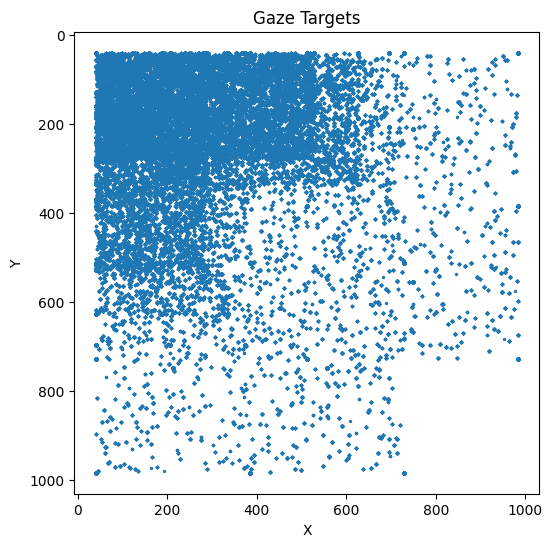

In [27]:

labels_file = "dataset/labels.csv"

df = pd.read_csv(labels_file)

# print(df.head())
# print("Anzahl Samples:", len(df))

x = df["x"]
y = df["y"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()


X_min: 0.0390625	 X_max: 0.9609375
Y_min: 0.0	 Y_max: 1.0


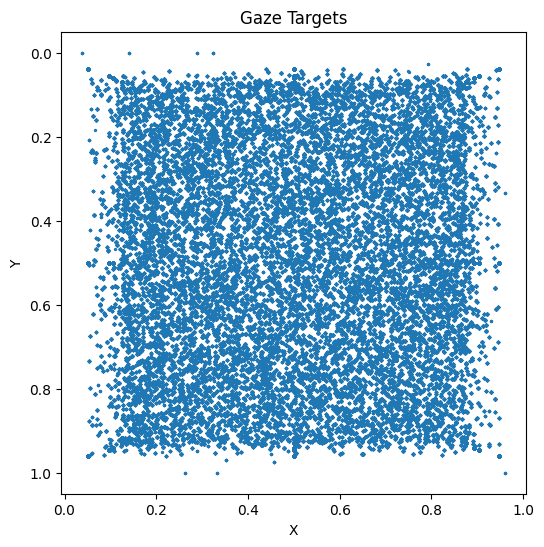

In [28]:
# Normalize:
import numpy as np

norm_labels_file = './dataset/norm_labels.csv'
df2 = pd.read_csv(norm_labels_file)

x = df2["x_norm"]
y = df2["y_norm"]

print(f"X_min: {np.min(x)}\t X_max: {np.max(x)}")
print(f"Y_min: {np.min(y)}\t Y_max: {np.max(y)}")

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=2)

plt.title("Gaze Targets")
plt.xlabel("X")
plt.ylabel("Y")

plt.gca().invert_yaxis()
plt.show()

In [33]:
# Konstant_Error:
#df2 = pd.read_csv(norm_labels_file)
x_true = df2["x_norm"].values
y_true = df2["y_norm"].values

x_const = np.mean(x_true)
y_const = np.mean(y_true)

# x_const = 0.5
# y_const = 0.5

print(f"x_const: {x_const}")
print(f"y_const: {y_const}")

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

const_errors = np.sqrt(
    (x_true - pred_x_const) ** 2 +
    (y_true - pred_y_const) ** 2
)


mae = np.mean(const_errors)
rmse = np.sqrt(np.mean(const_errors ** 2))
const_error_pct = 100 * np.round(rmse, 5)
const_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

print("\nRandom Baseline:\n")
print(f"Constant_Mean_Absolute_Error: {mae}")
print(f"Constant_Mean_Squared_Error: {rmse}")
print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")



# -------------------------------------------------------------------
# --------------- x- and y-constant: 0.0, 0.0 -----------------------
# -------------------------------------------------------------------

x_const = 0.0
y_const = 0.0

print(f"\nx_const: {x_const}")
print(f"y_const: {y_const}")

pred_x_const = np.full_like(x_true, x_const)
pred_y_const = np.full_like(y_true, y_const)

const_errors = np.sqrt(
    (x_true - pred_x_const) ** 2 +
    (y_true - pred_y_const) ** 2
)


mae = np.mean(const_errors)
rmse = np.sqrt(np.mean(const_errors ** 2))
const_error_pct = 100 * np.round(rmse, 5)
const_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

print("\nRandom Baseline:\n")
print(f"Constant_Mean_Absolute_Error: {mae}")
print(f"Constant_Mean_Squared_Error: {rmse}")
print(f"Constant_Mean_Squared_Error %: {const_error_pct} %")
print(f"Constant_Diagonal-Error %: {const_diagonal_error_pct} %")


x_const: 0.49942676242613293
y_const: 0.4991836176653093

Random Baseline:

Constant_Mean_Absolute_Error: 0.3564706456624816
Constant_Mean_Squared_Error: 0.38530152103324283
Constant_Mean_Squared_Error %: 38.53 %
Constant_Diagonal-Error %: 27.245 %

x_const: 0.0
y_const: 0.0

Random Baseline:

Constant_Mean_Absolute_Error: 0.7575864425829059
Constant_Mean_Squared_Error: 0.8044057665652362
Constant_Mean_Squared_Error %: 80.441 %
Constant_Diagonal-Error %: 56.879999999999995 %


In [34]:
# Random_Error:

x_max = 1.0
y_max = 1.0


pred_x_random = np.random.uniform(0, x_max, len(x_true))
pred_y_random = np.random.uniform(0, y_max, len(y_true))

random_errors = np.sqrt(
    (x_true - pred_x_random)**2 +
    (y_true - pred_y_random)**2
)

mae = np.mean(random_errors)
rmse = np.sqrt(np.mean(random_errors ** 2))
random_error_pct = 100 * np.round(rmse, 5)
random_diagonal_error_pct = 100 * np.round(rmse / np.sqrt(2), 5)

print("\nRandom Baseline:\n")
print(f"Random_Mean_Absolute_Error: {mae}")
print(f"Random_Mean_Squared_Error: {rmse}")
print(f"Random_Mean_Squared_Error %: {random_error_pct} %")
print(f"Random_Diagonal-Error %: {random_diagonal_error_pct} %")


Random Baseline:

Random_Mean_Absolute_Error: 0.5067053370671556
Random_Mean_Squared_Error: 0.5613016289153375
Random_Mean_Squared_Error %: 56.13 %
Random_Diagonal-Error %: 39.69 %


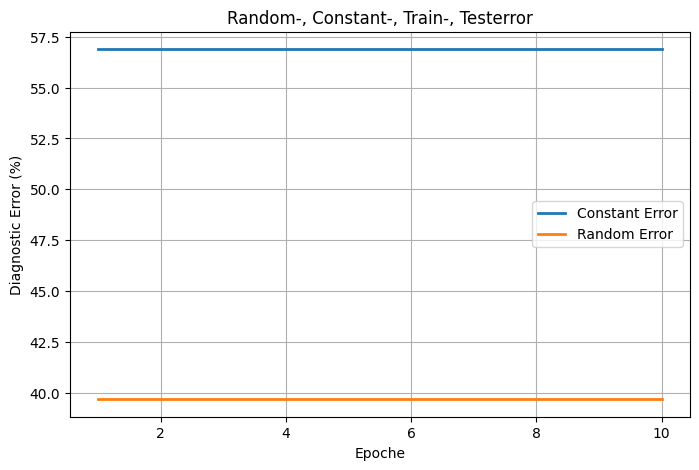

In [38]:
# epochs = range(1, len(diag_test_error) + 1)
epochs = range(1, 11)
plt.figure(figsize=(8, 5))

# plt.plot(diag_train_error, label="Train", linewidth=2)
# plt.plot(diag_test_error, label="Test", linewidth=2)


plt.plot(epochs, [const_diagonal_error_pct] * len(epochs),
         label="Constant Error", linewidth=2)

plt.plot(epochs, [random_diagonal_error_pct] * len(epochs),
         label="Random Error", linewidth=2)

# plt.plot(epochs, diag_test_error, marker='o', linewidth=2)

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")
plt.title("Random-, Constant-, Train-, Testerror")
plt.grid(True)
plt.legend()

plt.show()